# Notebook 02 — Feature Engineering and Modeling
**Level:** 2 (mandatory)  
**Depends on:** `01_data_understanding.ipynb` (must have run preprocessing pipeline)  

---

## Objectives
1. Load the cleaned dataset.
2. Engineer temporal and operational features.
3. Create a strict temporal split (train / val / test).
4. Train multiple models.
5. Evaluate and compare on validation set.
6. Select and persist the best model.
7. Run final evaluation on the held-out test set.

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.config import CFG
from src.feature_engineering import (
    build_features,
    temporal_split,
    prepare_Xy,
    run_feature_engineering_pipeline,
)
from src.train import train_all_models, save_model, log_to_mlflow
from src.evaluate import (
    compute_metrics,
    residuals_dataframe,
    build_metrics_table,
    save_metrics_table,
    error_by_time_block,
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
FIGURES_PATH = Path(CFG['paths']['reports_figures'])
TARGET = CFG['target']
print(f'Target: {TARGET}')

Target: % Silica Concentrate


---
## 1. Load Cleaned Data

In [5]:
interim_path = Path(CFG['paths']['data_interim']) / 'data_cleaned.parquet'

if not interim_path.exists():
    raise FileNotFoundError(
        'Cleaned data not found. Run notebook 01 first to generate data_cleaned.parquet.'
    )

df_clean = pd.read_parquet(interim_path)
print(f'Loaded cleaned data: {df_clean.shape}')
print(f'Date range: {df_clean.index.min()} → {df_clean.index.max()}')

Loaded cleaned data: (4097, 23)
Date range: 2017-03-10 01:00:00 → 2017-09-09 23:00:00


---
## 2. Feature Engineering

### Leakage Prevention Strategy

- Delayed lab measurements (`% Iron Concentrate`, `% Silica Concentrate`) are excluded as current predictors.
- Lag features use `shift(n)` with `n >= 1` (past-only).
- Rolling statistics are computed on `shift(1)` to exclude current observation.
- Temporal split is strict train/validation/test in chronological order.

### Feature availability assumptions

| Variable group | Examples | Availability at inference time | Decision in this notebook |
|---|---|---|---|
| Delayed lab measurements | `% Iron Concentrate`, `% Silica Concentrate` | No | Excluded as current predictors |
| Feed composition | `% Iron Feed`, `% Silica Feed` | Assumption-dependent | Main scenario includes them; sensitivity excludes them |
| Online process sensors | `Starch Flow`, `Amina Flow`, `Ore Pulp pH`, flotation columns | Yes (assumed) | Included |

### Sensitivity scenarios (anti-leakage robustness)

We train and compare four feature-availability scenarios on the same temporal split:
1. Feed ON + Target lags ON
2. Feed ON + Target lags OFF
3. Feed OFF + Target lags ON
4. Feed OFF + Target lags OFF

This shows whether model performance depends on assumptions that may not hold online.

In [6]:
# Build scenario datasets for feature-availability sensitivity

scenario_defs = [

    {"scenario": "Feed ON + TargetLags ON",  "include_feed": True,  "include_target_lags": True},

    {"scenario": "Feed ON + TargetLags OFF", "include_feed": True,  "include_target_lags": False},

    {"scenario": "Feed OFF + TargetLags ON", "include_feed": False, "include_target_lags": True},

    {"scenario": "Feed OFF + TargetLags OFF","include_feed": False, "include_target_lags": False},

]



scenario_data = {}

for sc in scenario_defs:

    X_train_sc, X_val_sc, X_test_sc, y_train_sc, y_val_sc, y_test_sc = run_feature_engineering_pipeline(

        df_clean,

        cfg=CFG,

        save=False,

        include_target_lags=sc['include_target_lags'],

        include_feed_features=sc['include_feed'],

    )

    scenario_data[sc['scenario']] = {

        'X_train': X_train_sc,

        'X_val': X_val_sc,

        'X_test': X_test_sc,

        'y_train': y_train_sc,

        'y_val': y_val_sc,

        'y_test': y_test_sc,

    }



# Keep default/main scenario for downstream compatibility

main_scenario = "Feed ON + TargetLags ON"

X_train = scenario_data[main_scenario]['X_train']

X_val   = scenario_data[main_scenario]['X_val']

X_test  = scenario_data[main_scenario]['X_test']

y_train = scenario_data[main_scenario]['y_train']

y_val   = scenario_data[main_scenario]['y_val']

y_test  = scenario_data[main_scenario]['y_test']



print(f"Main scenario: {main_scenario}")

print(f"X_train shape: {X_train.shape}")

print(f"X_val   shape: {X_val.shape}")

print(f"X_test  shape: {X_test.shape}")


[feature_engineering] Split sizes — train: 2867 (70%), val: 615 (15%), test: 615 (15%)
  Train: 2017-03-10 01:00:00 → 2017-07-20 17:00:00
  Val:   2017-07-20 18:00:00 → 2017-08-15 08:00:00
  Test:  2017-08-15 09:00:00 → 2017-09-09 23:00:00
[feature_engineering] Split sizes — train: 2867 (70%), val: 615 (15%), test: 615 (15%)
  Train: 2017-03-10 01:00:00 → 2017-07-20 17:00:00
  Val:   2017-07-20 18:00:00 → 2017-08-15 08:00:00
  Test:  2017-08-15 09:00:00 → 2017-09-09 23:00:00
[feature_engineering] Split sizes — train: 2867 (70%), val: 615 (15%), test: 615 (15%)
  Train: 2017-03-10 01:00:00 → 2017-07-20 17:00:00
  Val:   2017-07-20 18:00:00 → 2017-08-15 08:00:00
  Test:  2017-08-15 09:00:00 → 2017-09-09 23:00:00
[feature_engineering] Split sizes — train: 2867 (70%), val: 615 (15%), test: 615 (15%)
  Train: 2017-03-10 01:00:00 → 2017-07-20 17:00:00
  Val:   2017-07-20 18:00:00 → 2017-08-15 08:00:00
  Test:  2017-08-15 09:00:00 → 2017-09-09 23:00:00
Main scenario: Feed ON + TargetLags ON
X

---
## 3. Baseline Reference

We load the baseline metrics saved in notebook 01 as our performance floor.

In [7]:
metrics_path = Path(CFG['paths']['reports_metrics'])
with open(metrics_path / 'baseline_metrics.json', 'r') as f:
    baseline_metrics = json.load(f)

print('Baseline metrics (predict training mean):')
for split_name, m in baseline_metrics.items():
    print(f'  {split_name}: {m}')

Baseline metrics (predict training mean):
  Train: {'MAE': 0.923, 'RMSE': 1.1254, 'R2': 0.0}
  Val: {'MAE': 0.79, 'RMSE': 1.033, 'R2': -0.0023}
  Test: {'MAE': 0.9916, 'RMSE': 1.2011, 'R2': -0.0083}


---
## 4. Model Training

### Extra Trees benchmark

Se incluye **Extra Trees Regressor** como benchmark no lineal adicional de tipo ensemble para contrastar estabilidad frente a Random Forest.

Configuración conservadora para reducir overfitting: `n_estimators=300`, `min_samples_leaf=5`, `random_state=42`, `n_jobs=-1`.

In [8]:
# Train all models for each availability scenario (validation-only model selection)

scenario_training = {}

scenario_val_tables = {}



for scenario_name, data_sc in scenario_data.items():

    print(f"\n=== Training scenario: {scenario_name} ===")

    fitted_sc, metrics_sc = train_all_models(

        data_sc['X_train'], data_sc['y_train'], data_sc['X_val'], data_sc['y_val'], cfg=CFG

    )

    scenario_training[scenario_name] = {

        'fitted_models': fitted_sc,

        'all_metrics': metrics_sc,

    }



    val_results_sc = {name: m['val'] for name, m in metrics_sc.items()}

    table_sc = build_metrics_table(val_results_sc)

    table_sc.insert(0, 'Scenario', scenario_name)

    scenario_val_tables[scenario_name] = table_sc



# Keep main scenario variables for downstream compatibility

fitted_models = scenario_training[main_scenario]['fitted_models']

all_metrics = scenario_training[main_scenario]['all_metrics']



=== Training scenario: Feed ON + TargetLags ON ===

[train] Fitting: Baseline (Mean)
[train] Baseline (Mean) | train: {'MAE': 0.9241, 'RMSE': np.float64(1.1265), 'R2': 0.0} | val: {'MAE': 0.7908, 'RMSE': np.float64(1.0331), 'R2': -0.0025}

[train] Fitting: Ridge
[train] Ridge | train: {'MAE': 0.4789, 'RMSE': np.float64(0.6802), 'R2': 0.6354} | val: {'MAE': 0.5383, 'RMSE': np.float64(0.7282), 'R2': 0.502}

[train] Fitting: Random Forest
[train] Random Forest | train: {'MAE': 0.3468, 'RMSE': np.float64(0.5103), 'R2': 0.7948} | val: {'MAE': 0.4856, 'RMSE': np.float64(0.6626), 'R2': 0.5876}

[train] Fitting: Extra Trees Regressor
[train] Extra Trees Regressor | train: {'MAE': 0.1963, 'RMSE': np.float64(0.3161), 'R2': 0.9213} | val: {'MAE': 0.4818, 'RMSE': np.float64(0.6629), 'R2': 0.5873}

[train] Fitting: XGBoost
[train] XGBoost | train: {'MAE': 0.0306, 'RMSE': np.float64(0.0405), 'R2': 0.9987} | val: {'MAE': 0.6427, 'RMSE': np.float64(0.8075), 'R2': 0.3875}

[train] Fitting: LightGBM
[t

In [9]:
# Build and display validation metrics table (main scenario + sensitivity summary)

val_results = {name: metrics['val'] for name, metrics in all_metrics.items()}

metrics_table = build_metrics_table(val_results)

print('\n=== Validation Metrics (Main Scenario) ===')

display(metrics_table)



sensitivity_table = pd.concat(scenario_val_tables.values(), ignore_index=True)

print('\n=== Scenario Sensitivity (Validation) ===')

display(sensitivity_table)



# Best scenario/model pair by validation RMSE

best_row_global = sensitivity_table.sort_values('RMSE', ascending=True).iloc[0]

print(

    f"Best validation pair: Scenario={best_row_global['Scenario']} | "

    f"Model={best_row_global['Model']} | RMSE={best_row_global['RMSE']}"

)



# Overfitting diagnostics on selected scenario

selected_scenario_tmp = best_row_global['Scenario']

selected_metrics_all = scenario_training[selected_scenario_tmp]['all_metrics']

overfit_rows = []

for model_name, mm in selected_metrics_all.items():

    tr = mm['train']

    vv = mm['val']

    overfit_rows.append({

        'Model': model_name,

        'Train_R2': tr.get('R2', np.nan),

        'Val_R2': vv.get('R2', np.nan),

        'R2_gap_train_minus_val': round(tr.get('R2', np.nan) - vv.get('R2', np.nan), 4),

        'Train_RMSE': tr.get('RMSE', np.nan),

        'Val_RMSE': vv.get('RMSE', np.nan),

        'RMSE_ratio_val_over_train': round(vv.get('RMSE', np.nan) / tr.get('RMSE', np.nan), 4) if tr.get('RMSE', 0) else np.nan,

    })

overfit_table = pd.DataFrame(overfit_rows).sort_values('Val_R2', ascending=False)

print('\n=== Overfitting diagnostics (selected scenario) ===')

display(overfit_table)



=== Validation Metrics (Main Scenario) ===


,Model,MAE,RMSE,R2
0,Random Forest,0.4856,0.6626,0.5876
1,Extra Trees Regressor,0.4818,0.6629,0.5873
2,Ridge,0.5383,0.7282,0.5020
3,LightGBM,0.5752,0.7470,0.4758
4,XGBoost,0.6427,0.8075,0.3875
5,Baseline (Mean),0.7908,1.0331,-0.0025



=== Scenario Sensitivity (Validation) ===


,Scenario,Model,MAE,RMSE,R2
0,Feed ON + TargetLags ON,Random Forest,0.4856,0.6626,0.5876
1,Feed ON + TargetLags ON,Extra Trees Regressor,0.4818,0.6629,0.5873
2,Feed ON + TargetLags ON,Ridge,0.5383,0.7282,0.5020
3,Feed ON + TargetLags ON,LightGBM,0.5752,0.7470,0.4758
4,Feed ON + TargetLags ON,XGBoost,0.6427,0.8075,0.3875
5,Feed ON + TargetLags ON,Baseline (Mean),0.7908,1.0331,-0.0025
6,Feed ON + TargetLags OFF,Random Forest,0.7709,1.0006,0.0595
7,Feed ON + TargetLags OFF,Baseline (Mean),0.7908,1.0331,-0.0025
8,Feed ON + TargetLags OFF,Extra Trees Regressor,0.8096,1.0423,-0.0205
9,Feed ON + TargetLags OFF,LightGBM,0.8293,1.0713,-0.0779


Best validation pair: Scenario=Feed ON + TargetLags ON | Model=Random Forest | RMSE=0.6626

=== Overfitting diagnostics (selected scenario) ===


,Model,Train_R2,Val_R2,R2_gap_train_minus_val,Train_RMSE,Val_RMSE,RMSE_ratio_val_over_train
2,Random Forest,0.7948,0.5876,0.2072,0.5103,0.6626,1.2985
3,Extra Trees Regressor,0.9213,0.5873,0.3340,0.3161,0.6629,2.0971
1,Ridge,0.6354,0.5020,0.1334,0.6802,0.7282,1.0706
5,LightGBM,0.9998,0.4758,0.5240,0.0178,0.7470,41.9663
4,XGBoost,0.9987,0.3875,0.6112,0.0405,0.8075,19.9383
0,Baseline (Mean),0.0000,-0.0025,0.0025,1.1265,1.0331,0.9171


---
## 5. Model Evaluation Beyond a Single Metric

We analyse: real vs predicted, residuals, temporal error patterns, and block comparisons.

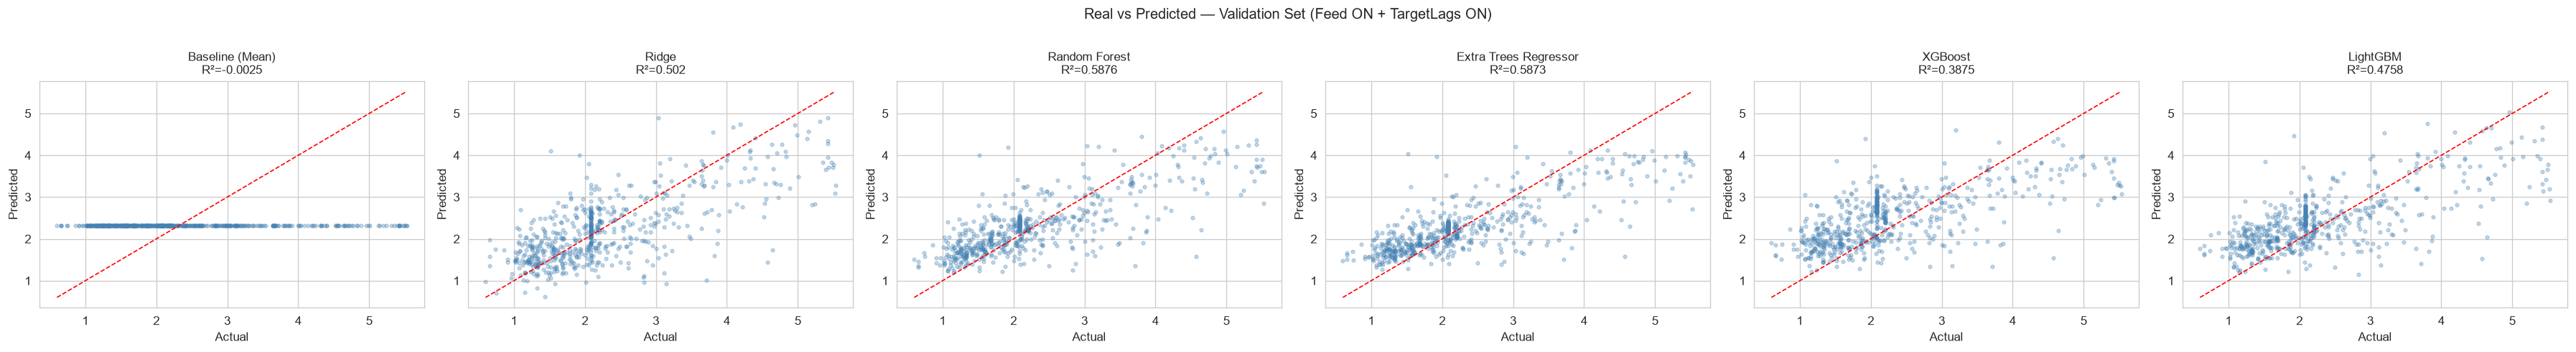

In [10]:
# ── 5a. Real vs Predicted — selected scenario models on validation set ──────

selected_scenario = best_row_global['Scenario']

selected_pack = scenario_training[selected_scenario]

fitted_models_selected = selected_pack['fitted_models']



X_val_sel = scenario_data[selected_scenario]['X_val']

y_val_sel = scenario_data[selected_scenario]['y_val']



n_models = len(fitted_models_selected)

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

if n_models == 1:

    axes = [axes]



for ax, (name, model) in zip(axes, fitted_models_selected.items()):

    y_pred = model.predict(X_val_sel)

    ax.scatter(y_val_sel, y_pred, alpha=0.3, s=8, color='steelblue')

    lims = [min(y_val_sel.min(), y_pred.min()), max(y_val_sel.max(), y_pred.max())]

    ax.plot(lims, lims, 'r--', lw=1, label='Perfect')

    r2 = compute_metrics(y_val_sel, y_pred)['R2']

    ax.set_title(f'{name}\nR²={r2}', fontsize=10)

    ax.set_xlabel('Actual')

    ax.set_ylabel('Predicted')



plt.suptitle(f'Real vs Predicted — Validation Set ({selected_scenario})', y=1.01, fontsize=12)

plt.tight_layout()

plt.savefig(FIGURES_PATH / 'real_vs_predicted_val.png', dpi=150, bbox_inches='tight')

plt.show()


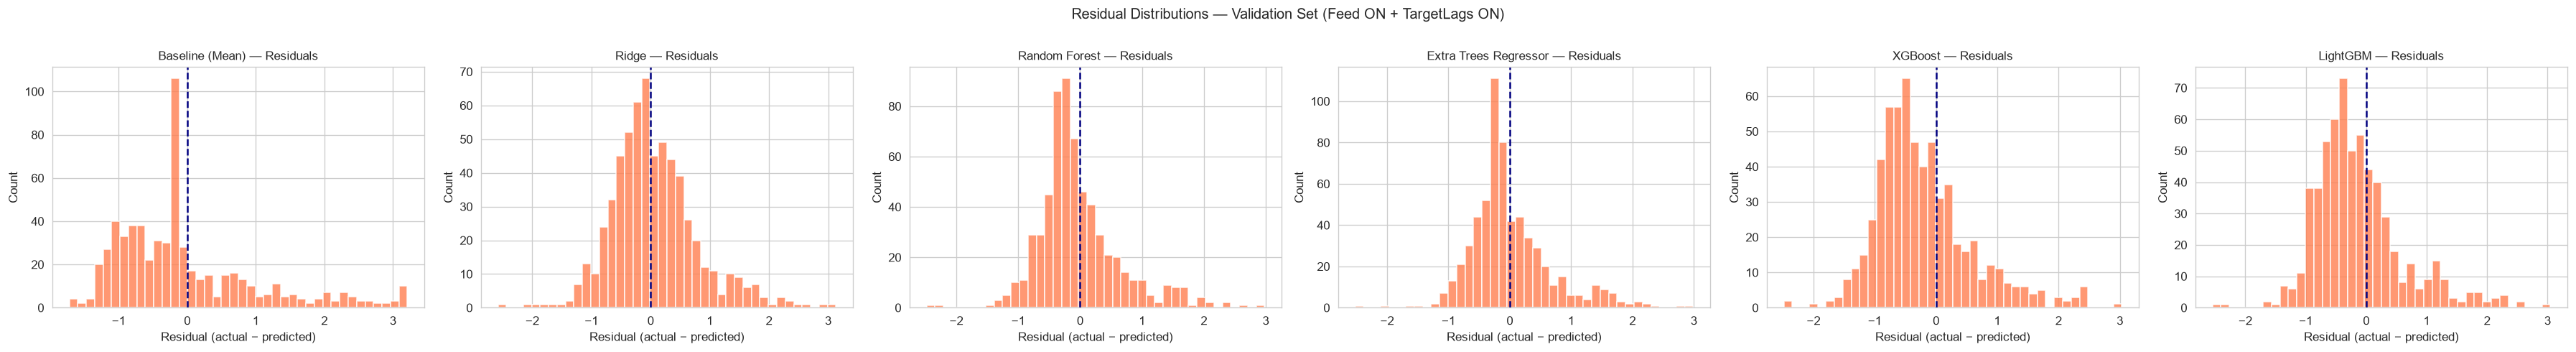

In [11]:
# ── 5b. Residuals distribution — selected scenario ──────────────────────────

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

if n_models == 1:

    axes = [axes]



for ax, (name, model) in zip(axes, fitted_models_selected.items()):

    y_pred = model.predict(X_val_sel)

    res = y_val_sel.values - y_pred

    ax.hist(res, bins=40, color='coral', edgecolor='white', alpha=0.8)

    ax.axvline(0, color='navy', lw=1.5, linestyle='--')

    ax.set_title(f'{name} — Residuals', fontsize=10)

    ax.set_xlabel('Residual (actual − predicted)')

    ax.set_ylabel('Count')



plt.suptitle(f'Residual Distributions — Validation Set ({selected_scenario})', y=1.01, fontsize=12)

plt.tight_layout()

plt.savefig(FIGURES_PATH / 'residuals_distribution.png', dpi=150, bbox_inches='tight')

plt.show()


Selected scenario (validation): Feed ON + TargetLags ON
Selected model by validation RMSE: Random Forest


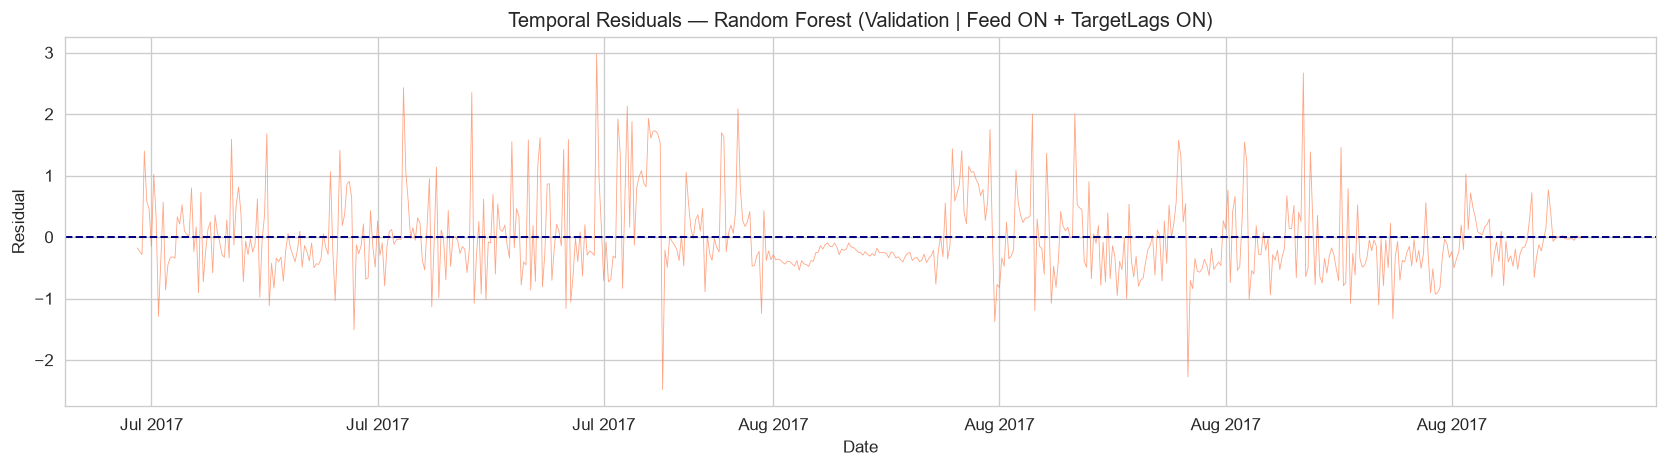

In [12]:
# ── 5c. Temporal residual error — best model from best validation pair ──────

best_name = best_row_global['Model']

best_model = fitted_models_selected[best_name]

print(f"Selected scenario (validation): {selected_scenario}")

print(f"Selected model by validation RMSE: {best_name}")



y_pred_best = best_model.predict(X_val_sel)

res_df = residuals_dataframe(y_val_sel, y_pred_best, split_name='val')



fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(res_df.index, res_df['residual'], lw=0.5, color='coral', alpha=0.7)

ax.axhline(0, color='navy', lw=1.2, linestyle='--')

ax.set_title(f'Temporal Residuals — {best_name} (Validation | {selected_scenario})', fontsize=12)

ax.set_xlabel('Date')

ax.set_ylabel('Residual')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()

plt.savefig(FIGURES_PATH / 'temporal_residuals.png', dpi=150, bbox_inches='tight')

plt.show()


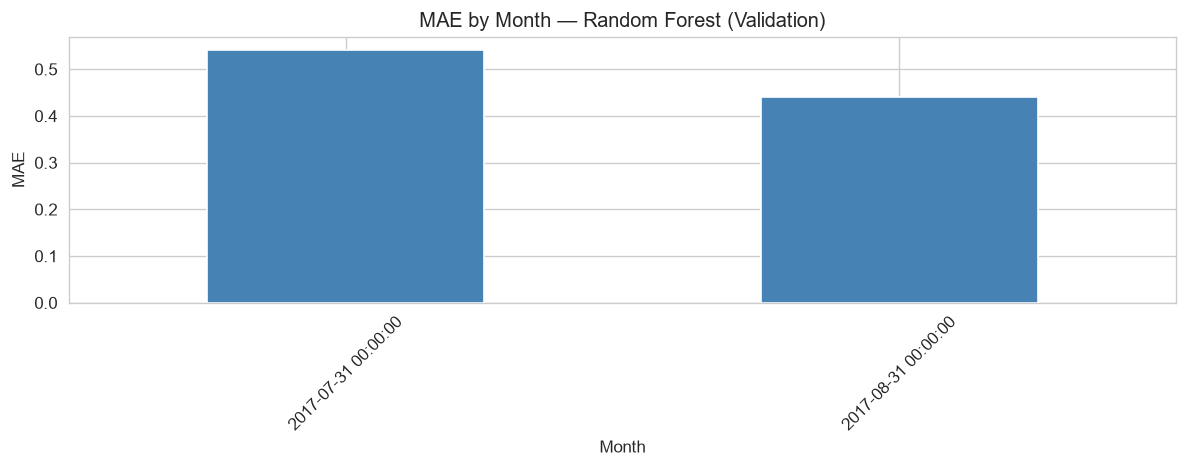

,MAE,RMSE,n_obs
date,,,
2017-07-31,0.542072,0.755722,270
2017-08-31,0.441319,0.579472,345


In [17]:
# ── 5d. Error by monthly block ────────────────────────────────────────────
monthly_error = error_by_time_block(res_df, freq='ME')

fig, ax = plt.subplots(figsize=(10, 4))
monthly_error['MAE'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'MAE by Month — {best_name} (Validation)', fontsize=12)
ax.set_ylabel('MAE')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'mae_by_month.png', dpi=150, bbox_inches='tight')
plt.show()
monthly_error

---
## 6. Model Selection and Final Test Evaluation

**Selection protocol (strict temporal validation):**
- Model selection is based on validation RMSE only (no test tuning).
- Test set is used once, after model + scenario are fixed.

**Overfitting diagnostic:**
If a model shows near-perfect train $R^2$ but significantly lower validation $R^2$, we treat it as overfitting risk and prioritise models with better temporal generalization.

**Leakage robustness checks included:**
- Main run: Feed ON + Target lags ON
- Sensitivity: with/without feed variables and with/without target lags

Interpretation is predictive only: variables are considered **associated with** and **contributing to predictions**, not causal drivers.

In [18]:
# Final evaluation on test set (evaluated ONCE, after validation-based selection)

X_test_sel = scenario_data[selected_scenario]['X_test']

y_test_sel = scenario_data[selected_scenario]['y_test']



y_pred_test = best_model.predict(X_test_sel)

test_metrics = compute_metrics(y_test_sel, y_pred_test)



print(f"\n=== Final Test Set Metrics — {best_name} ({selected_scenario}) ===")

print(f"MAE:  {test_metrics['MAE']}")

print(f"RMSE: {test_metrics['RMSE']}")

print(f"R²:   {test_metrics['R2']}")



print(f"\nBaseline Test (from nb01):")

print(f"  MAE:  {baseline_metrics['Test']['MAE']}")

print(f"  RMSE: {baseline_metrics['Test']['RMSE']}")

print(f"  R²:   {baseline_metrics['Test']['R2']}")



=== Final Test Set Metrics — Random Forest (Feed ON + TargetLags ON) ===
MAE:  0.55
RMSE: 0.7474
R²:   0.6096

Baseline Test (from nb01):
  MAE:  0.9916
  RMSE: 1.2011
  R²:   -0.0083


In [19]:
# Add test metrics to the comparison table and save (selected scenario)

test_results = {

    name: compute_metrics(y_test_sel, model.predict(X_test_sel))

    for name, model in fitted_models_selected.items()

}

full_table = build_metrics_table(test_results)

full_table.insert(0, 'split', 'test')

full_table.insert(0, 'Scenario', selected_scenario)

save_metrics_table(full_table, CFG)

display(full_table)



# Improvement vs baseline (validation + test)

baseline_val = baseline_metrics['Val']

baseline_test = baseline_metrics['Test']



val_improvement = sensitivity_table[sensitivity_table['Scenario'] == selected_scenario].copy()

val_improvement['MAE_improvement_vs_baseline_pct'] = (

    (baseline_val['MAE'] - val_improvement['MAE']) / baseline_val['MAE'] * 100

).round(2)

val_improvement['RMSE_improvement_vs_baseline_pct'] = (

    (baseline_val['RMSE'] - val_improvement['RMSE']) / baseline_val['RMSE'] * 100

).round(2)



test_improvement = full_table.copy()

test_improvement['MAE_improvement_vs_baseline_pct'] = (

    (baseline_test['MAE'] - test_improvement['MAE']) / baseline_test['MAE'] * 100

).round(2)

test_improvement['RMSE_improvement_vs_baseline_pct'] = (

    (baseline_test['RMSE'] - test_improvement['RMSE']) / baseline_test['RMSE'] * 100

).round(2)



print('\n=== Validation improvement vs baseline (%) — selected scenario ===')

display(val_improvement[['Scenario', 'Model', 'MAE', 'RMSE', 'R2', 'MAE_improvement_vs_baseline_pct', 'RMSE_improvement_vs_baseline_pct']])



print('\n=== Test improvement vs baseline (%) ===')

display(test_improvement[['Scenario', 'Model', 'MAE', 'RMSE', 'R2', 'MAE_improvement_vs_baseline_pct', 'RMSE_improvement_vs_baseline_pct']])


[evaluate] Metrics saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\model_comparison.csv


,Scenario,split,Model,MAE,RMSE,R2
0,Feed ON + TargetLags ON,test,Random Forest,0.5500,0.7474,0.6096
1,Feed ON + TargetLags ON,test,Extra Trees Regressor,0.5539,0.7483,0.6086
2,Feed ON + TargetLags ON,test,LightGBM,0.5726,0.7619,0.5943
3,Feed ON + TargetLags ON,test,XGBoost,0.6491,0.8199,0.5302
4,Feed ON + TargetLags ON,test,Ridge,0.6627,0.9145,0.4156
5,Feed ON + TargetLags ON,test,Baseline (Mean),0.9919,1.2009,-0.0080



=== Validation improvement vs baseline (%) — selected scenario ===


,Scenario,Model,MAE,RMSE,R2,MAE_improvement_vs_baseline_pct,RMSE_improvement_vs_baseline_pct
0,Feed ON + TargetLags ON,Random Forest,0.4856,0.6626,0.5876,38.53,35.86
1,Feed ON + TargetLags ON,Extra Trees Regressor,0.4818,0.6629,0.5873,39.01,35.83
2,Feed ON + TargetLags ON,Ridge,0.5383,0.7282,0.5020,31.86,29.51
3,Feed ON + TargetLags ON,LightGBM,0.5752,0.7470,0.4758,27.19,27.69
4,Feed ON + TargetLags ON,XGBoost,0.6427,0.8075,0.3875,18.65,21.83
5,Feed ON + TargetLags ON,Baseline (Mean),0.7908,1.0331,-0.0025,-0.10,-0.01



=== Test improvement vs baseline (%) ===


,Scenario,Model,MAE,RMSE,R2,MAE_improvement_vs_baseline_pct,RMSE_improvement_vs_baseline_pct
0,Feed ON + TargetLags ON,Random Forest,0.5500,0.7474,0.6096,44.53,37.77
1,Feed ON + TargetLags ON,Extra Trees Regressor,0.5539,0.7483,0.6086,44.14,37.70
2,Feed ON + TargetLags ON,LightGBM,0.5726,0.7619,0.5943,42.25,36.57
3,Feed ON + TargetLags ON,XGBoost,0.6491,0.8199,0.5302,34.54,31.74
4,Feed ON + TargetLags ON,Ridge,0.6627,0.9145,0.4156,33.17,23.86
5,Feed ON + TargetLags ON,Baseline (Mean),0.9919,1.2009,-0.0080,-0.03,0.02


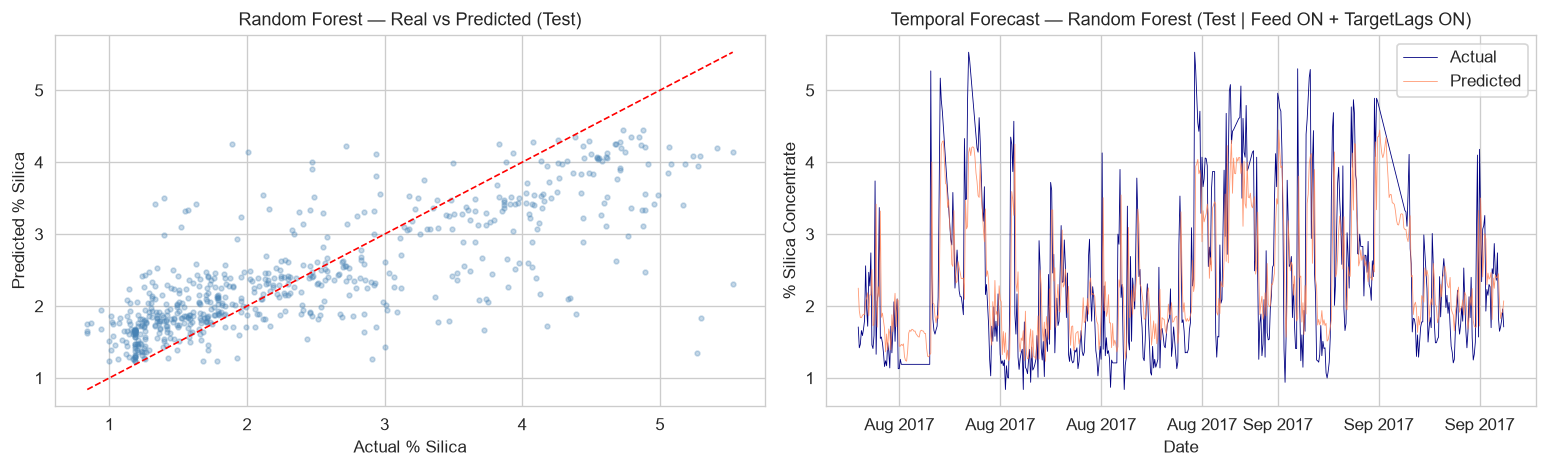

In [20]:
# Real vs Predicted — Test set (selected validation winner)

res_df_test = residuals_dataframe(y_test_sel, y_pred_test, split_name='test')



fig, axes = plt.subplots(1, 2, figsize=(13, 4))



# Scatter

axes[0].scatter(y_test_sel, y_pred_test, alpha=0.3, s=8, color='steelblue')

lims = [min(y_test_sel.min(), y_pred_test.min()), max(y_test_sel.max(), y_pred_test.max())]

axes[0].plot(lims, lims, 'r--', lw=1)

axes[0].set_title(f'{best_name} — Real vs Predicted (Test)', fontsize=11)

axes[0].set_xlabel('Actual % Silica')

axes[0].set_ylabel('Predicted % Silica')



# Temporal prediction trace

axes[1].plot(res_df_test.index, res_df_test['y_true'], lw=0.5, label='Actual', color='navy')

axes[1].plot(res_df_test.index, res_df_test['y_pred'], lw=0.5, label='Predicted', color='coral', alpha=0.8)

axes[1].set_title(f'Temporal Forecast — {best_name} (Test | {selected_scenario})', fontsize=11)

axes[1].set_xlabel('Date')

axes[1].set_ylabel('% Silica Concentrate')

axes[1].legend()

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))



plt.tight_layout()

plt.savefig(FIGURES_PATH / 'real_vs_predicted_test.png', dpi=150, bbox_inches='tight')

plt.show()


---
## 7. Save Selected Model

In [21]:
model_path = save_model(best_model, model_name=best_name, folder='selected', cfg=CFG)



# Also save feature list alongside model for reproducibility

import json

feature_list_path = Path(CFG['paths']['models_selected']) / 'feature_columns.json'

X_train_selected = scenario_data[selected_scenario]['X_train']

with open(feature_list_path, 'w') as f:

    json.dump(list(X_train_selected.columns), f, indent=2)

print(f'Feature list saved to: {feature_list_path}')

print(f'Selected scenario saved: {selected_scenario}')


[train] Model saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\models\selected\model.pkl
Feature list saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\models\selected\feature_columns.json
Selected scenario saved: Feed ON + TargetLags ON


In [22]:
# Log to MLflow

train_metrics_best = selected_metrics_all[best_name]['train']

val_metrics_best   = selected_metrics_all[best_name]['val']

log_to_mlflow(best_model, best_name, train_metrics_best, val_metrics_best, cfg=CFG)


[train] mlflow not installed — skipping tracking.


---
## Summary — Level 2 Checklist

| Item | Status |
|---|---|
| Temporal split (train/val/test) | ✅ |
| No random split (`train_test_split` not used) | ✅ |
| Model set includes Baseline, Ridge, RF, Extra Trees, XGBoost, LightGBM | ✅ |
| Lag features and rolling statistics (past-only) | ✅ |
| MAE, RMSE, R² evaluation | ✅ |
| Real vs predicted, residuals, temporal error analysis | ✅ |
| Improvement vs baseline table (MAE/RMSE %) | ✅ |
| Sensitivity: feed ON/OFF and target lags ON/OFF | ✅ |
| Final model selection based on validation only | ✅ |
| Test used only after final selection | ✅ |
| Model saved to `models/selected/` | ✅ |

### Executive conclusions (Level 2)

- **Selected model:** winner is chosen by validation RMSE over all candidates and scenarios.
- **Extra Trees benchmark:** added as additional non-linear ensemble to compare stability vs Random Forest.
- **Improvement vs baseline:** reported for MAE and RMSE on validation and final test.
- **Overfitting signals:** reviewed through train-vs-validation gap table.
- **Next step:** Level 3 Explainability (global and local SHAP) with predictive, non-causal language.